<a href="https://colab.research.google.com/github/Denniskag/Python-Project-for-Data-Science/blob/main/Fraud_detection_in_Mobile_Money_Transactions_using_differentially_Private_Machine_learning_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing libraries**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.metrics import roc_curve, auc

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
!pip install diffprivlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
!pip show diffprivlib

Name: diffprivlib
Version: 0.6.6
Summary: IBM Differential Privacy Library
Home-page: https://github.com/IBM/differential-privacy-library
Author: Naoise Holohan
Author-email: naoise.holohan@ibm.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scikit-learn, scipy, setuptools
Required-by: 


In [ ]:
import diffprivlib
print(diffprivlib.__version__)

0.6.6


In [ ]:
from diffprivlib.utils import PrivacyLeakWarning
warnings.filterwarnings("ignore", category=PrivacyLeakWarning)

**Importing dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MCS Research Project dataset/MoMTSim_20240722202413_1000_dataset.csv')

In [ ]:
df.shape

(4225958, 10)

**Dataset  description**

In [ ]:
df['initiator_balance_diff'] = df['oldBalInitiator'] - df['newBalInitiator']
df['Recipient_balance_diff'] = df['oldBalRecipient'] - df['newBalRecipient']
df['amount_to_oldBal_ratio'] = df['amount'] / (df['oldBalInitiator'] + 1e-6)
df['amount_to_newBal_ratio'] = df['amount'] / (df['newBalInitiator'] + 1e-6)
mean_amount = df['amount'].mean()
std_amount = df['amount'].std()
df['large_transaction'] = (df['amount'] > mean_amount + 2 * std_amount).astype(int)

In [ ]:
df.shape

(4225958, 15)

In [ ]:
df.columns

Index(['step', 'transactionType', 'amount', 'initiator', 'oldBalInitiator',
       'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient',
       'isFraud', 'initiator_balance_diff', 'Recipient_balance_diff',
       'amount_to_oldBal_ratio', 'amount_to_newBal_ratio',
       'large_transaction'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
step,0
transactionType,0
amount,0
initiator,0
oldBalInitiator,0
newBalInitiator,0
recipient,0
oldBalRecipient,0
newBalRecipient,0
isFraud,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225958 entries, 0 to 4225957
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   step                    int64  
 1   transactionType         object 
 2   amount                  float64
 3   initiator               int64  
 4   oldBalInitiator         float64
 5   newBalInitiator         float64
 6   recipient               object 
 7   oldBalRecipient         float64
 8   newBalRecipient         float64
 9   isFraud                 int64  
 10  initiator_balance_diff  float64
 11  Recipient_balance_diff  float64
 12  amount_to_oldBal_ratio  float64
 13  amount_to_newBal_ratio  float64
 14  large_transaction       int64  
dtypes: float64(9), int64(4), object(2)
memory usage: 483.6+ MB


In [ ]:
cols_to_drop = ['initiator', 'recipient']

df_model = df.drop(columns=cols_to_drop)

**One hot encoding for categorical column**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

encoded_sparse = encoder.fit_transform(df_model[['transactionType']])

encoded_cols = encoder.get_feature_names_out(['transactionType'])

encoded_df = pd.DataFrame.sparse.from_spmatrix(encoded_sparse, columns=encoded_cols)

df_final = pd.concat([df_model.drop(columns=['transactionType']), encoded_df], axis=1)

df_final.head()


,step,amount,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud,initiator_balance_diff,Recipient_balance_diff,amount_to_oldBal_ratio,amount_to_newBal_ratio,large_transaction,transactionType_DEBIT,transactionType_DEPOSIT,transactionType_PAYMENT,transactionType_TRANSFER,transactionType_WITHDRAWAL
0,0,579.16,29.32,29.32,0.00,0.00,0,0.00,0.00,19.753069,1.975307e+01,0,0,0,1.0,0,0
1,0,39.03,39.03,0.00,55.94,94.98,1,39.03,-39.04,1.000000,3.903000e+07,0,0,0,0,1.0,0
2,0,21.78,21.78,0.00,58.09,79.88,1,21.78,-21.79,1.000000,2.178000e+07,0,0,0,0,1.0,0
3,0,570.22,5.29,5.29,0.00,0.00,0,0.00,0.00,107.792040,1.077920e+02,0,0,0,1.0,0,0
4,0,574.80,82.63,82.63,0.00,0.00,0,0.00,0.00,6.956311,6.956311e+00,0,0,0,1.0,0,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression as LR
from sklearn.naive_bayes import GaussianNB as NB
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn.ensemble import RandomForestClassifier as RF

**Preparing X and Y for training**

In [ ]:
x = df_final.drop(columns=['isFraud'])
y = df_final['isFraud']

**Building models**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state =42)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


**Non dp**


=== Logistic Regression ===
Accuracy:      0.9504
Precision:     0.9317
Recall:        0.9779
F1 Score:      0.9542
MCC:           0.9015
ROC-AUC:       0.9933

=== Gaussian Naive Bayes ===
Accuracy:      0.9366
Precision:     0.8944
Recall:        0.9977
F1 Score:      0.9432
MCC:           0.8785
ROC-AUC:       0.9412

=== Decision Tree ===
Accuracy:      0.9689
Precision:     0.9886
Recall:        0.9521
F1 Score:      0.9700
MCC:           0.9385
ROC-AUC:       0.9963

=== Random Forest ===
Accuracy:      0.9691
Precision:     0.9893
Recall:        0.9520
F1 Score:      0.9702
MCC:           0.9390
ROC-AUC:       0.9963


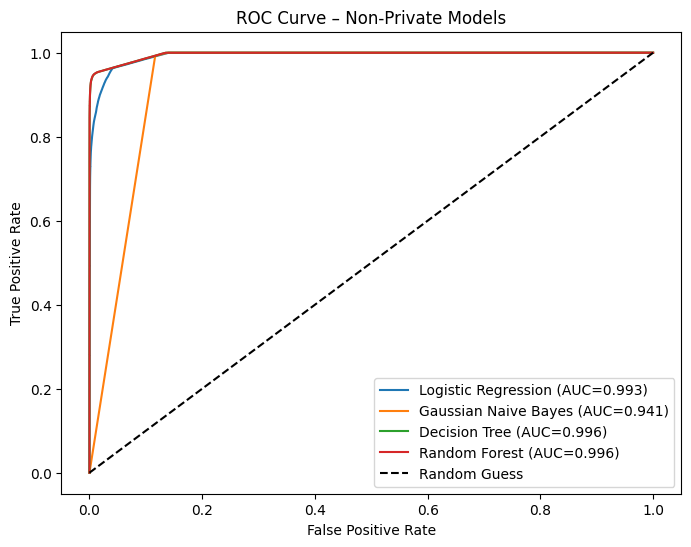

In [ ]:
normal_models = {
    "Logistic Regression": LR(max_iter=1000),
    "Gaussian Naive Bayes": NB(),
    "Decision Tree": DT(max_depth=8),
    "Random Forest": RF(n_estimators=100, max_depth=12)
}

plt.figure(figsize=(8,6))

for name, model in normal_models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)


    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    mcc  = matthews_corrcoef(y_test, y_pred)


    print(f"Accuracy:      {acc:.4f}")
    print(f"Precision:     {prec:.4f}")
    print(f"Recall:        {rec:.4f}")
    print(f"F1 Score:      {f1:.4f}")
    print(f"MCC:           {mcc:.4f}")


    try:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC:       {auc:.4f}")

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    except:
        print("ROC-AUC:       Not supported (no predict_proba)")
        continue

plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.title("ROC Curve – Non-Private Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**DP MODELS**

In [ ]:
from diffprivlib.models import LogisticRegression as DP_LR, GaussianNB as DP_NB, DecisionTreeClassifier as DP_DT, RandomForestClassifier as DP_RF


=== DP Logistic Regression ===
Accuracy:  0.4930
Precision: 0.9999
Recall:    0.0406
F1 Score:  0.0780
MCC:       0.1398
AUC:       0.9795

=== DP Gaussian Naive Bayes ===
Accuracy:  0.9429
Precision: 0.9115
Recall:    0.9878
F1 Score:  0.9481
MCC:       0.8883
AUC:       0.9867

=== DP Decision Tree ===
Accuracy:  0.9511
Precision: 0.9330
Recall:    0.9776
F1 Score:  0.9548
MCC:       0.9027
AUC:       0.9495

=== DP Random Forest ===
Accuracy:  0.9026
Precision: 0.8444
Recall:    1.0000
F1 Score:  0.9156
MCC:       0.8186
AUC:       0.9917


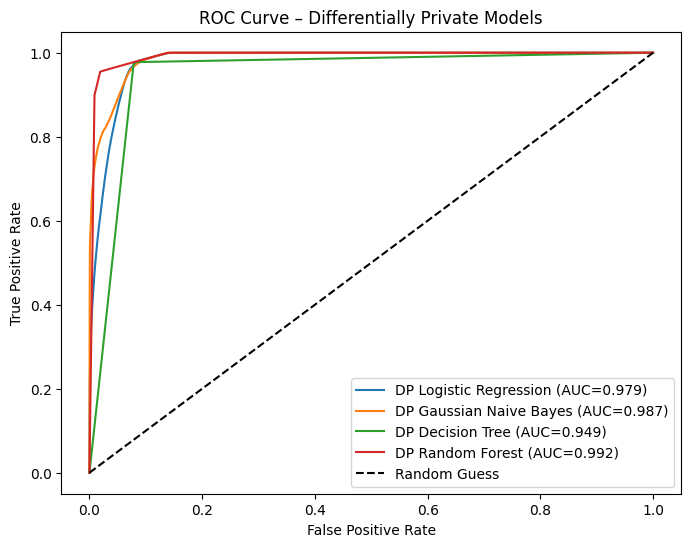

In [ ]:
dp_models = {
    "DP Logistic Regression": DP_LR,
    "DP Gaussian Naive Bayes": DP_NB,
    "DP Decision Tree": DP_DT,
    "DP Random Forest": DP_RF
}

plt.figure(figsize=(8,6))
dp_metrics = {}

for name, model_class in dp_models.items():


    model = (
        model_class(epsilon=1.0, data_norm=1.0)
        if name == "DP Logistic Regression" else
        model_class(epsilon=1.0, max_depth=8)
        if "Tree" in name else
        model_class(epsilon=1.0, n_estimators=20, max_depth=8)
        if "Forest" in name else
        model_class(epsilon=1.0)
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)


    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    mcc  = matthews_corrcoef(y_test, y_pred)


    try:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
        auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)

        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    except:
        auc = np.nan


    dp_metrics[name] = {
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1 Score":  f1,
        "MCC":       mcc,
        "AUC":       auc
    }


    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"MCC:       {mcc:.4f}")
    print(f"AUC:       {auc:.4f}")



plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.title("ROC Curve – Differentially Private Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**accuracy vs epsilon**

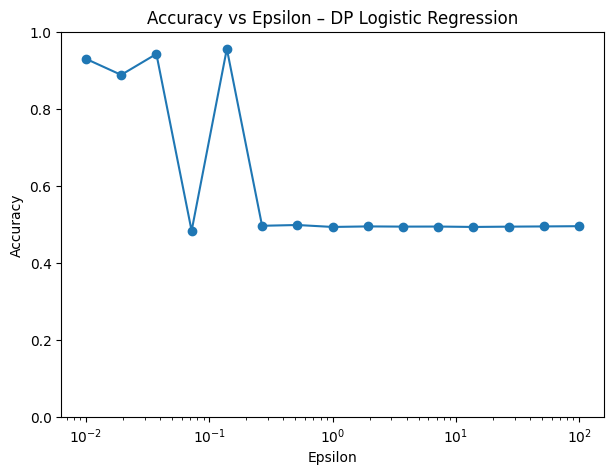

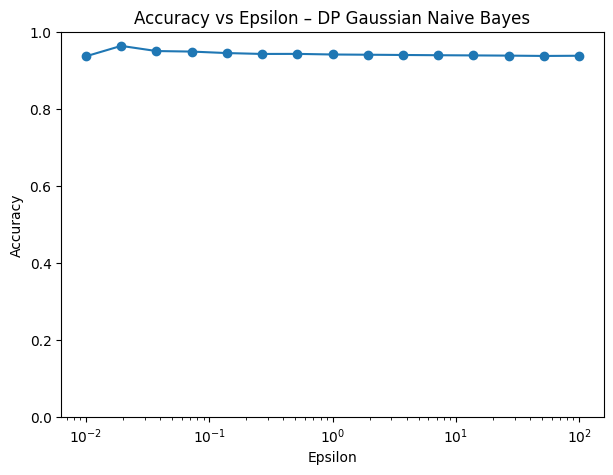

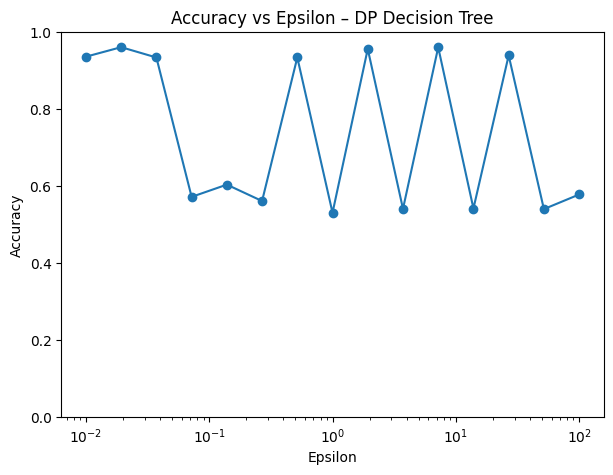

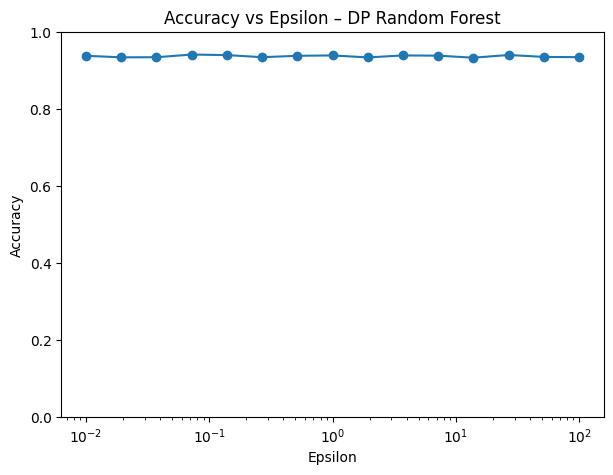

In [ ]:
epsilons = np.logspace(-2, 2, 15)

for name, model_class in dp_models.items():
    accuracies = []

    for eps in epsilons:
        model = model_class(epsilon=eps, data_norm=1.0) if name=="DP Logistic Regression" else \
                model_class(epsilon=eps, max_depth=8) if "Tree" in name else \
                model_class(epsilon=eps, n_estimators=20, max_depth=8) if "Forest" in name else \
                model_class(epsilon=eps)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)


    plt.figure(figsize=(7,5))
    plt.semilogx(epsilons, accuracies, marker='o')
    plt.title(f"Accuracy vs Epsilon – {name}")
    plt.xlabel("Epsilon")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.show()